In [10]:
import networkx as nx
from etc_utils.hamiltonian import precompute, H, gamma_balancer
import numpy as np
import matplotlib.pyplot as plt

In [3]:
G = nx.barbell_graph(25, 5)  # or any torture-case graph
A, Dinv2, nodes, idx = precompute(G)

In [4]:
A.shape          # should be (n, n)

(55, 55)

In [5]:
Dinv2.shape      # dense, same

(55, 55)

In [6]:
np.allclose(Dinv2.T, Dinv2)  # should be False (upper only)

False

In [7]:
np.diag(Dinv2).sum()         # should be 0.0

np.float64(0.0)

In [8]:
k = 30
S_idx = np.random.choice(len(nodes), k, replace=False)

mu = 1.0
gamma = gamma_balancer(G, k, mu)  # baseline guess

H_total, T1, T2 = H(A, Dinv2, S_idx, mu=mu, gamma=gamma)
print(f"H = {H_total:.3f},  T1 = {T1:.3f},  T2 = {T2:.3f}")

H = 1094.024,  T1 = -187.000,  T2 = 1281.024


In [ ]:
Hs, T1s, T2s = [], [], []
for _ in range(200):
    S_idx = np.random.choice(len(nodes), k, replace=False)
    h, t1, t2 = H(A, Dinv2, S_idx, mu=mu, gamma=gamma)
    Hs.append(h)
    T1s.append(t1)
    T2s.append(t2)

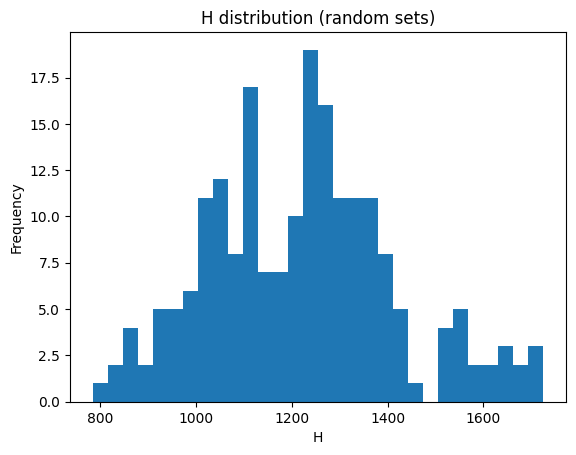

In [11]:
plt.hist(Hs, bins=30)
plt.title("H distribution (random sets)")
plt.xlabel("H")
plt.ylabel("Frequency")
plt.show()

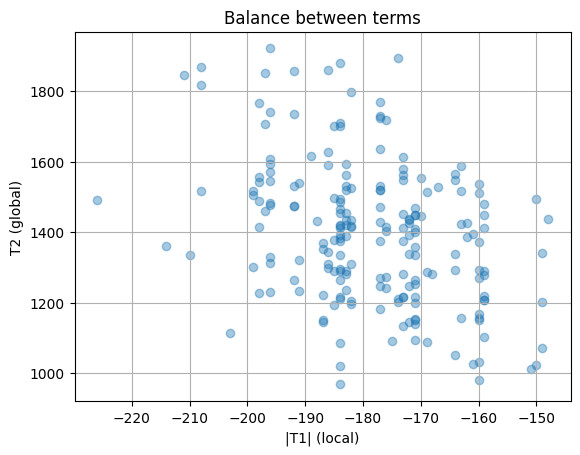

In [13]:
plt.scatter(T1s, T2s, alpha=0.4)
plt.xlabel("|T1| (local)")
plt.ylabel("T2 (global)")
plt.title("Balance between terms")
plt.grid(True)
plt.show()

In [14]:
sub = Dinv2[np.ix_(S_idx, S_idx)]
print(np.round(sub, 2))

[[0.   0.   0.02 0.   0.   0.02 0.   0.   0.02 0.02 0.02 0.   0.06 0.
  1.   0.   0.   0.02 0.02 0.02 0.   0.   0.02 0.02 0.   0.02 0.   0.
  0.   0.25]
 [1.   0.   0.02 1.   1.   0.02 0.   0.   0.02 0.02 0.02 0.   0.04 1.
  0.25 0.   0.   0.02 0.02 0.02 0.   0.   0.02 0.02 1.   0.02 0.   1.
  1.   0.11]
 [0.   0.   0.   0.   0.   0.   0.   0.   1.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   1.   0.   0.   1.   1.   0.   1.   0.   0.
  0.   0.  ]
 [1.   0.   0.02 0.   0.   0.02 0.   0.   0.02 0.02 0.02 0.   0.04 0.
  0.25 0.   0.   0.02 0.02 0.02 0.   0.   0.02 0.02 0.   0.02 0.   0.
  1.   0.11]
 [1.   0.   0.02 1.   0.   0.02 0.   0.   0.02 0.02 0.02 0.   0.04 0.
  0.25 0.   0.   0.02 0.02 0.02 0.   0.   0.02 0.02 0.   0.02 0.   1.
  1.   0.11]
 [0.   0.   1.   0.   0.   0.   0.   0.   1.   1.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   1.   0.   0.   1.   1.   0.   1.   0.   0.
  0.   0.  ]
 [1.   1.   0.02 1.   1.   0.02 0.   1.   0.02 0.02 0.02 1.   0.04 1.
  0.25 0.   

In [15]:
def equal_contribution_gamma(G, k, mu=1.0, iters=300, span=(0.1, 10), n_grid=10, seed=1):
    """
    Sweeps gamma and returns the one that balances |T1| and T2 medians across random subsets.

    Parameters
    ----------
    G : networkx.Graph
        Your input graph.
    k : int
        Number of nodes in the subset.
    mu : float
        Value of mu (usually 1.0).
    iters : int
        How many random subsets to sample per gamma.
    span : tuple
        The sweep range in log space (relative to gamma_balancer baseline).
    n_grid : int
        Number of gamma values to try.
    seed : int
        Random seed.

    Returns
    -------
    gamma_star : float
        The gamma that minimizes |median(|T1|) - median(T2)|
    details : dict
        All gammas, medians and errors for plotting/debug
    """
    rng = np.random.default_rng(seed)
    A, Dinv2, nodes, idx = precompute(G)
    gamma0 = gamma_balancer(G, k, mu)

    gamma_list = gamma0 * np.logspace(np.log10(span[0]), np.log10(span[1]), n_grid)
    errors, med_T1, med_T2 = [], [], []

    for gamma in gamma_list:
        T1s, T2s = [], []
        for _ in range(iters):
            S = rng.choice(len(nodes), size=k, replace=False)
            _, t1, t2 = H(A, Dinv2, S, mu=mu, gamma=gamma)
            T1s.append(abs(t1))
            T2s.append(t2)
        med1 = np.median(T1s)
        med2 = np.median(T2s)
        err = abs(med1 - med2)

        errors.append(err)
        med_T1.append(med1)
        med_T2.append(med2)

    best_idx = int(np.argmin(errors))
    return gamma_list[best_idx], {
        "gammas": gamma_list,
        "errors": errors,
        "med_T1": med_T1,
        "med_T2": med_T2,
        "best_gamma": gamma_list[best_idx]
    }

In [16]:
G = nx.barbell_graph(25, 5)
k = 30
mu = 1.0

gamma_opt, info = equal_contribution_gamma(G, k, mu=mu, iters=300)

print("Optimal gamma =", gamma_opt)

Optimal gamma = 1.4828482325977657


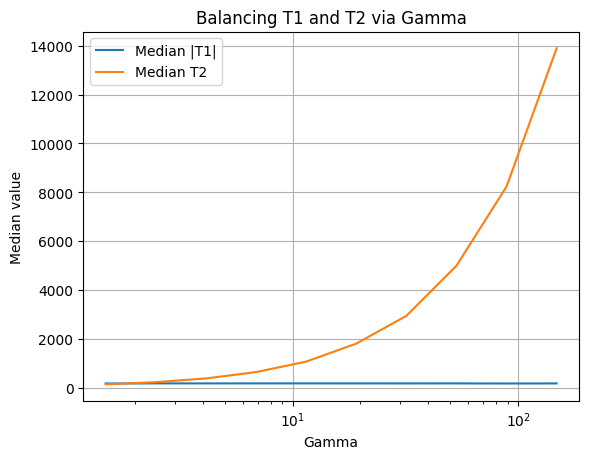

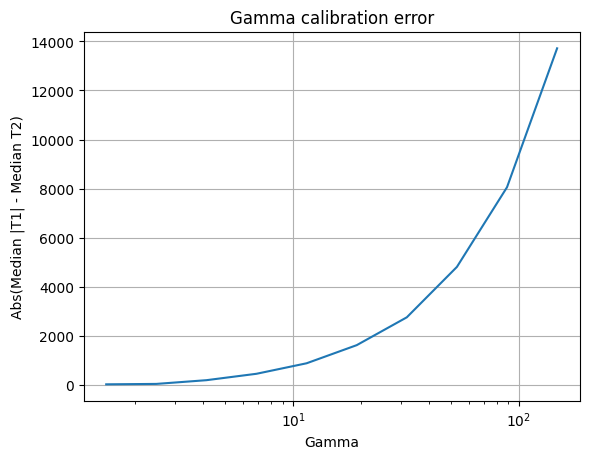

In [17]:
plt.plot(info["gammas"], info["med_T1"], label="Median |T1|")
plt.plot(info["gammas"], info["med_T2"], label="Median T2")
plt.xscale("log")
plt.xlabel("Gamma")
plt.ylabel("Median value")
plt.title("Balancing T1 and T2 via Gamma")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(info["gammas"], info["errors"])
plt.xscale("log")
plt.xlabel("Gamma")
plt.ylabel("Abs(Median |T1| - Median T2)")
plt.title("Gamma calibration error")
plt.grid(True)
plt.show()
